<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/HOUSING(Linear).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, classification_report,
                              confusion_matrix)

In [4]:
house = pd.read_csv("HOUSE_clean.csv")
house.head()
house.info()
house.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 83 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1460 non-null   int64  
 1   MSSubClass        1460 non-null   int64  
 2   MSZoning          1460 non-null   object 
 3   LotFrontage       1201 non-null   float64
 4   LotArea           1460 non-null   int64  
 5   Street            1460 non-null   object 
 6   Alley             91 non-null     object 
 7   LotShape          1460 non-null   object 
 8   LandContour       1460 non-null   object 
 9   Utilities         1460 non-null   object 
 10  LotConfig         1460 non-null   object 
 11  LandSlope         1460 non-null   object 
 12  Neighborhood      1460 non-null   object 
 13  Condition1        1460 non-null   object 
 14  Condition2        1460 non-null   object 
 15  BldgType          1460 non-null   object 
 16  HouseStyle        1460 non-null   object 


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,GrLivArea_scaled,GrLivArea_minmax
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,8,2007,WD,Normal,175000,0.250402,0.247362
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,MnPrv,NaN,0,2,2010,WD,Normal,210000,1.061367,0.327619
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,GdPrv,Shed,2500,5,2010,WD,Normal,266500,1.569647,0.377920
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,4,2010,WD,Normal,142125,-0.832788,0.140166
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,6,2008,WD,Normal,147500,-0.493934,0.173700


In [5]:
features = ["OverallQual", "GrLivArea", "GarageCars",
            "TotalBsmtSF", "FullBath", "YearBuilt"]

X = house[features].fillna(house[features].median())
y = house["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # random split — no time dimension
)
scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)
model2 = LinearRegression()
model2.fit(X_train_scaled, y_train)


LinearRegression()

In [7]:
y_pred2 = model2.predict(X_test_scaled)
r2_house = r2_score(y_test, y_pred2)
rmse_house = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f"R²:   {r2_house:.3f}")
print(f"RMSE: USD {rmse_house:,.0f}")


R²:   0.794
RMSE: USD 39,711


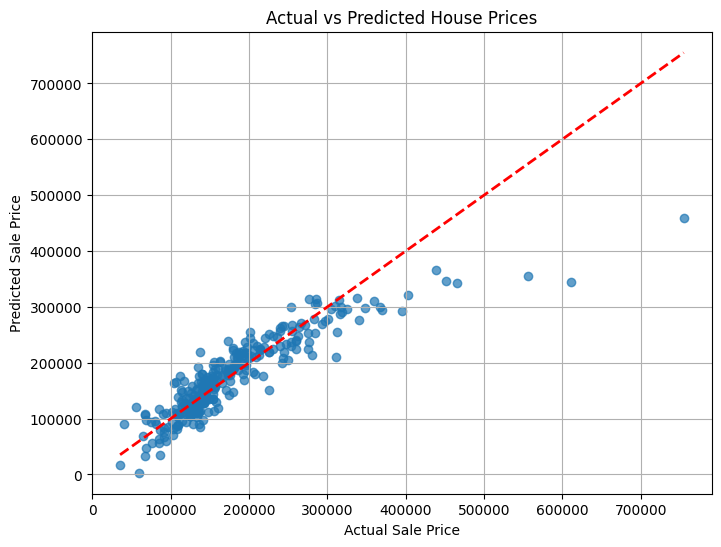

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred2, alpha=0.7)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.grid(True)
plt.show()